# **Project Title : Internship Project -  Auto PricePred**
### **Project Description** :
- This project uses an Automobile Imports dataset containing various car features, including insurance risk ratings and price indicators, to predict car prices.

##  Project Team Id , Project Id and Deadlines

- **Project Team ID** : PTID-AIE-MAY-26-11218
- **Project ID** : PRCP-1017-Auto PricePred
- **Institute** : DataMites

## **Goal :**

* To develop a predictive model that accurately estimates car prices based on various independent variables.

## Imports and Configurations

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("auto_imports.csv")

In [3]:
df

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [4]:
columns_name = [ "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"]

In [5]:
df = pd.read_csv("auto_imports.csv",header = None)

In [6]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [7]:
df.columns = columns_name

In [8]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


## Domain Analysis

- Symboling: Numerical Indicates the insurance risk rating of the car (−3 = safest, +3 = risky).

- Normalized-losses Numerical Represents the average insurance loss payment per insured car.

- Make Categorical The brand or manufacturer of the car (e.g., Toyota, BMW, Honda)

- Fuel-type Categorical Type of fuel used by the car — gas or diesel.

- Aspiration Categorical Engine aspiration: standard (normal air intake) or turbo (forced air intake).
                                                                                   
- Num-Of-Doors Categorical Number of doors — two or four.
        
- Body-style Categorical Design or shape of the car — sedan, hatchback, convertible, etc.
    
- Drive-wheels Categorical Which wheels drive the car — front (fwd), rear (rwd), or 4-wheel (4wd).

- Engine-Location Categorical Location of the engine — front or rear.
                                                                                             
- Wheel-base Numerical Distance between front and rear wheels (in inches).

- Length Numerical Overall length of the car (in inches).

- Width Numerical Width of the car (in inches).

- Height Numerical Height of the car (in inches).

- Curb-weight Numerical Weight of the car without passengers or cargo (in pounds).

- engine-Type Categorical Configuration of the engine — dohc, ohcv, rotor, etc.

- Num-Of-Cylinders Categorical Number of cylinders in the engine (three, four, six, etc.).

- Engine-Size Numerical Engine displacement measured in cubic centimeters (cc).

- Fuel-System Categorical Type of fuel delivery system — mpfi, 2bbl, idi, etc.

- Bore Numerical Diameter of the engine cylinder.

- Stroke Numerical Movement of piston inside cylinder.

- Compression-Ratio Numerical Ratio of engine cylinder volume when piston is down vs. up.
    
- Horsepower Numerical Engine power output.
    
- Peak-Rpm Numerical Maximum revolutions per minute of the engine.
    
- City-Mpg Numerical Fuel efficiency in city driving (miles per gallon).
    
- Highway-Mpg Numerical Fuel efficiency on highway driving (miles per gallon).
    
- Price Numerical(Target Variable) Selling price of the car in USD.

# **Basic Check**

In [9]:
pd.set_option('display.max_columns', None) ## displaying all rows

In [10]:
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,176.8,64.8,54.3,2395,ohc,four,108,mpfi,3.5,2.8,8.8,101,5800,23,29,16430


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

**Insights**

- Total Number of Row : 200
- Total Number of features : 26
- Number of features (int64 + float64) : 11
- Categorical Features : 15
- There are incorect values some of dataseat and we will hendel in feature engineering section  

In [12]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


**insights**
    
   - The dataset includes a wide variety of cars, from big, potent luxury vehicles to small, light, fuel-efficient models.

   - The three main factors that affect a vehicle's cost—price, engine size, and curb weight—variably vary greatly.

   - The length, width, and height, on the other hand, show little variation because most cars follow the same body proportions.

In [13]:
df.describe(include = 'O').T

,count,unique,top,freq
normalized-losses,201,52,?,37
make,201,22,toyota,32
fuel-type,201,2,gas,181
aspiration,201,2,std,165
num-of-doors,201,3,four,113
body-style,201,5,sedan,94
drive-wheels,201,3,fwd,118
engine-location,201,2,front,198
engine-type,201,6,ohc,145
num-of-cylinders,201,7,four,157


**insights**
  - Dataset has mixed categorical and numeric columns (some numeric stored as text).

  - Most cars are gasoline, front-engine, 4-cylinder sedans from brands like Toyota.

  - Columns like normalized-losses, bore, stroke, horsepower, peak-rpm need data cleaning (type conversion and missing value handling).

In [14]:
df.shape

(201, 26)

# EDA - Exploratory Data Analysis

In [15]:
cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm',]

# replace ? with NaN
df[cols] = df[cols].replace('?', np.nan)

# convert to numeric
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# fill missing values (median)
df[cols] = df[cols].fillna(df[cols].median())

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [17]:
num_dis = df.select_dtypes(include=["int64"]).columns
num_counti = df.select_dtypes(include=["float64"]).columns
cat_cols = df.select_dtypes(include=['object']).columns


print('numeric dis columns: \n', num_dis)
print(len(num_dis))
print('numeric counti columns: \n', num_counti)
print(len(num_counti))      
print('categorical columns: \n', cat_cols)
print(len(cat_cols))

numeric dis columns: 
 Index(['symboling', 'curb-weight', 'engine-size', 'city-mpg', 'highway-mpg',
       'price'],
      dtype='object')
6
numeric counti columns: 
 Index(['normalized-losses', 'wheel-base', 'length', 'width', 'height', 'bore',
       'stroke', 'compression-ratio', 'horsepower', 'peak-rpm'],
      dtype='object')
10
categorical columns: 
 Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')
10


## **Univariate Analysis**

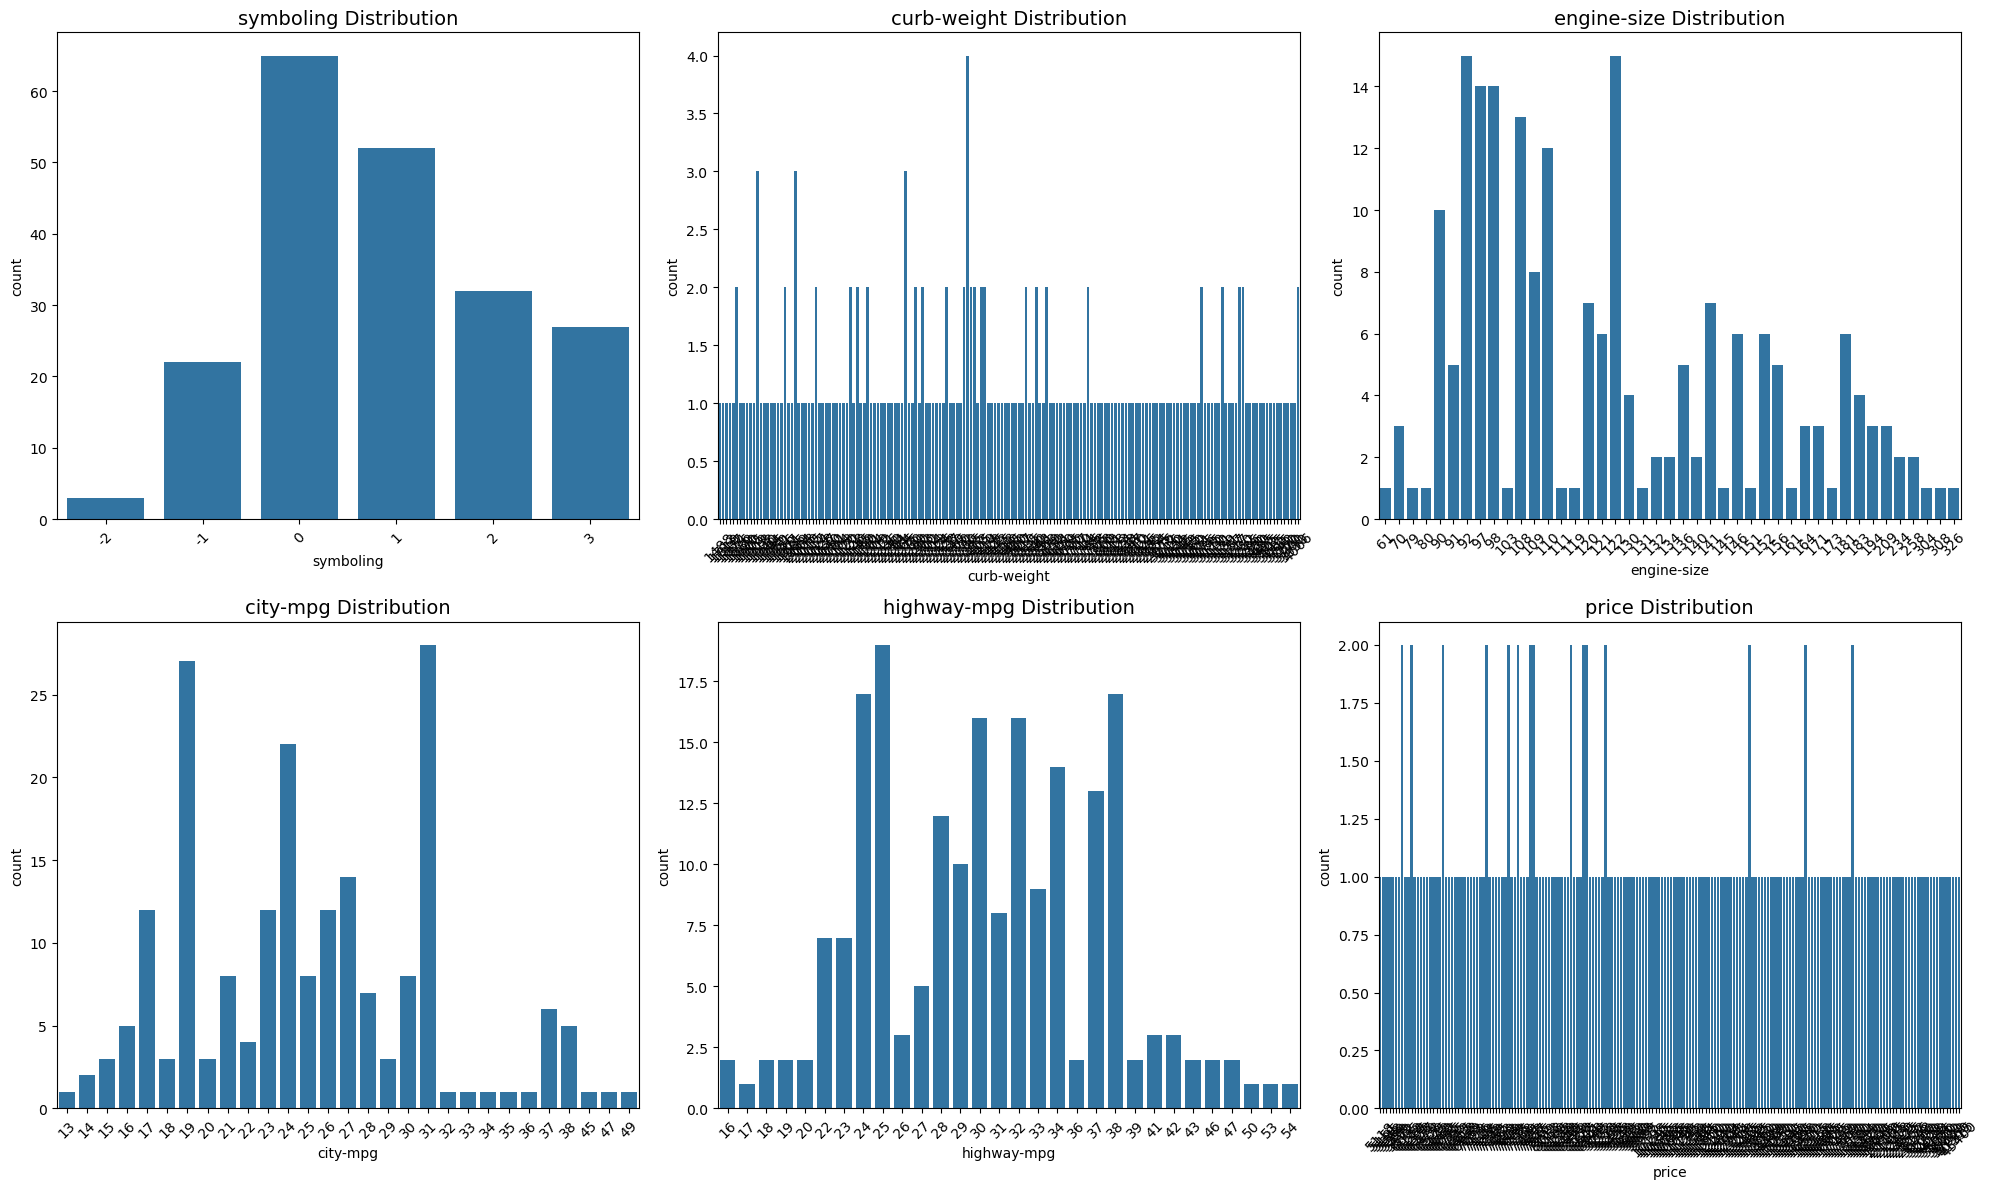

In [18]:
pltn = 1
plt.figure(figsize=(20, 12))

for col in num_dis:
    plt.subplot(2, 3, pltn) # Adjusted to 2x3 since you have 6 columns
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Distribution', fontsize=14)
    plt.xticks(rotation=45) # Helps if labels are crowded
    pltn += 1

plt.tight_layout()
plt.show()

**Insights**
  
- Symboling shows how risky the cars are, and most cars are in the medium risk category.
- Curb-weight distribution shows many cars have medium weight, and very heavy cars are fewer.
- Engine-size values are mostly small to medium, and large engine cars are less common.
- City-mpg and highway-mpg show most cars give average mileage, while very high mileage cars are limited.
- Price distribution shows most cars are in the mid-price range, and very expensive cars are few

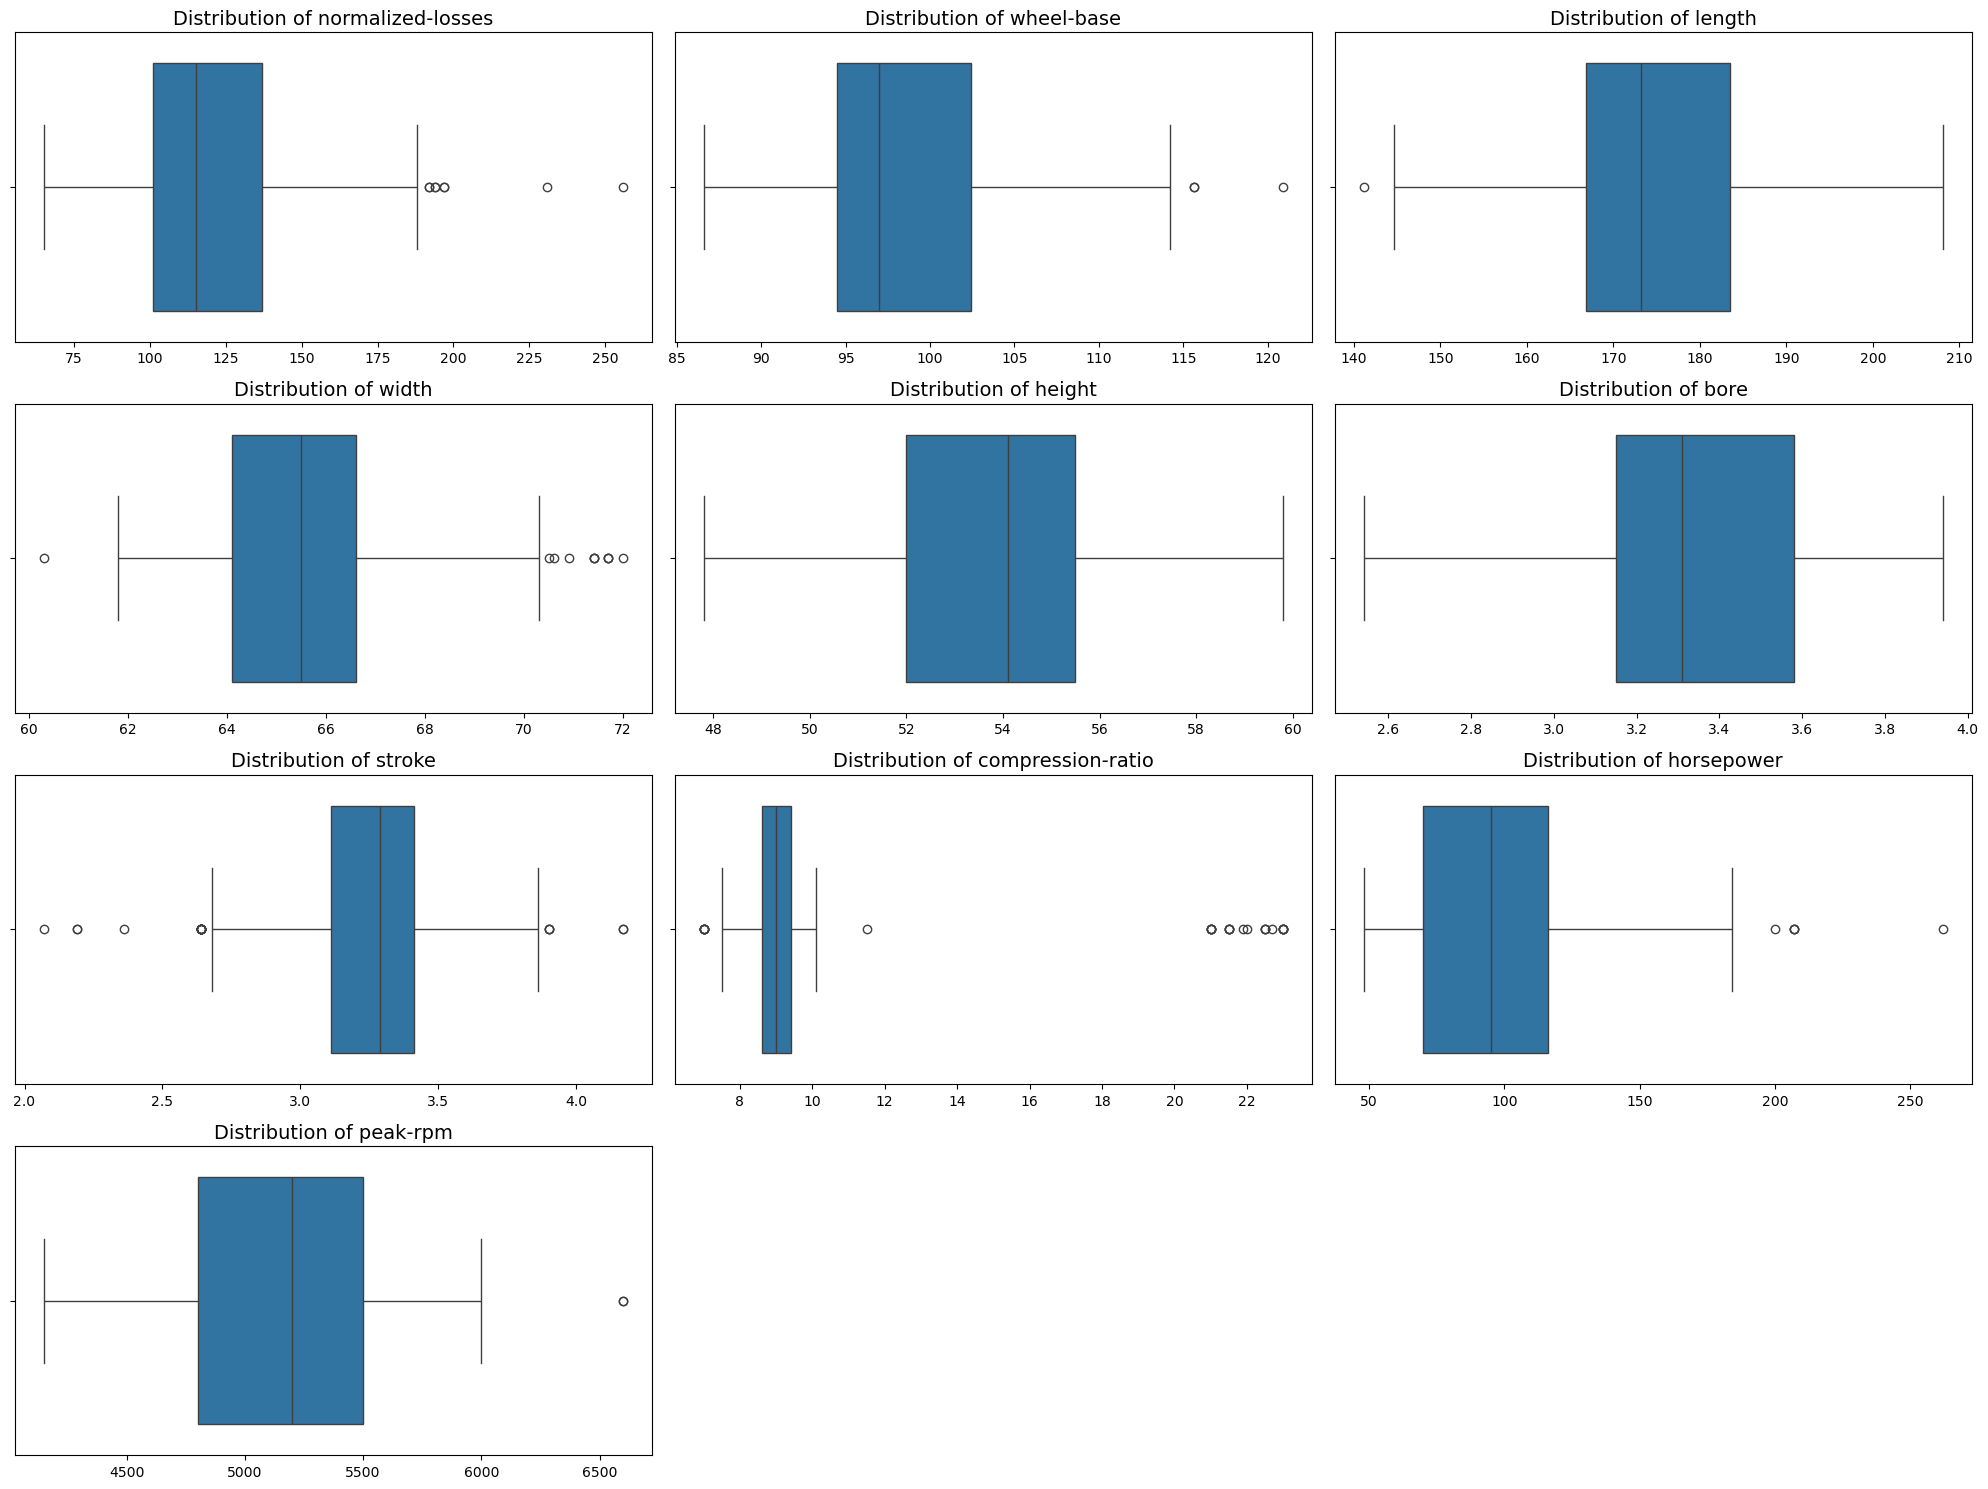

In [19]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(num_counti, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col], orient="h")
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel('')

plt.tight_layout()
plt.show()

**Insights**

- Some features like normalized-losses, horsepower, and peak-rpm contain many outliers (extreme values).
- Features such as length, width, wheel-base, and horsepower show high variation, meaning values differ a lot.
- Height, bore, and stroke have low spread, so their values are almost similar.
- Compression-ratio is right-skewed, with a few very high values compared to others.
- Outliers and different value ranges indicate the need for outlier handling and feature scaling before model training.

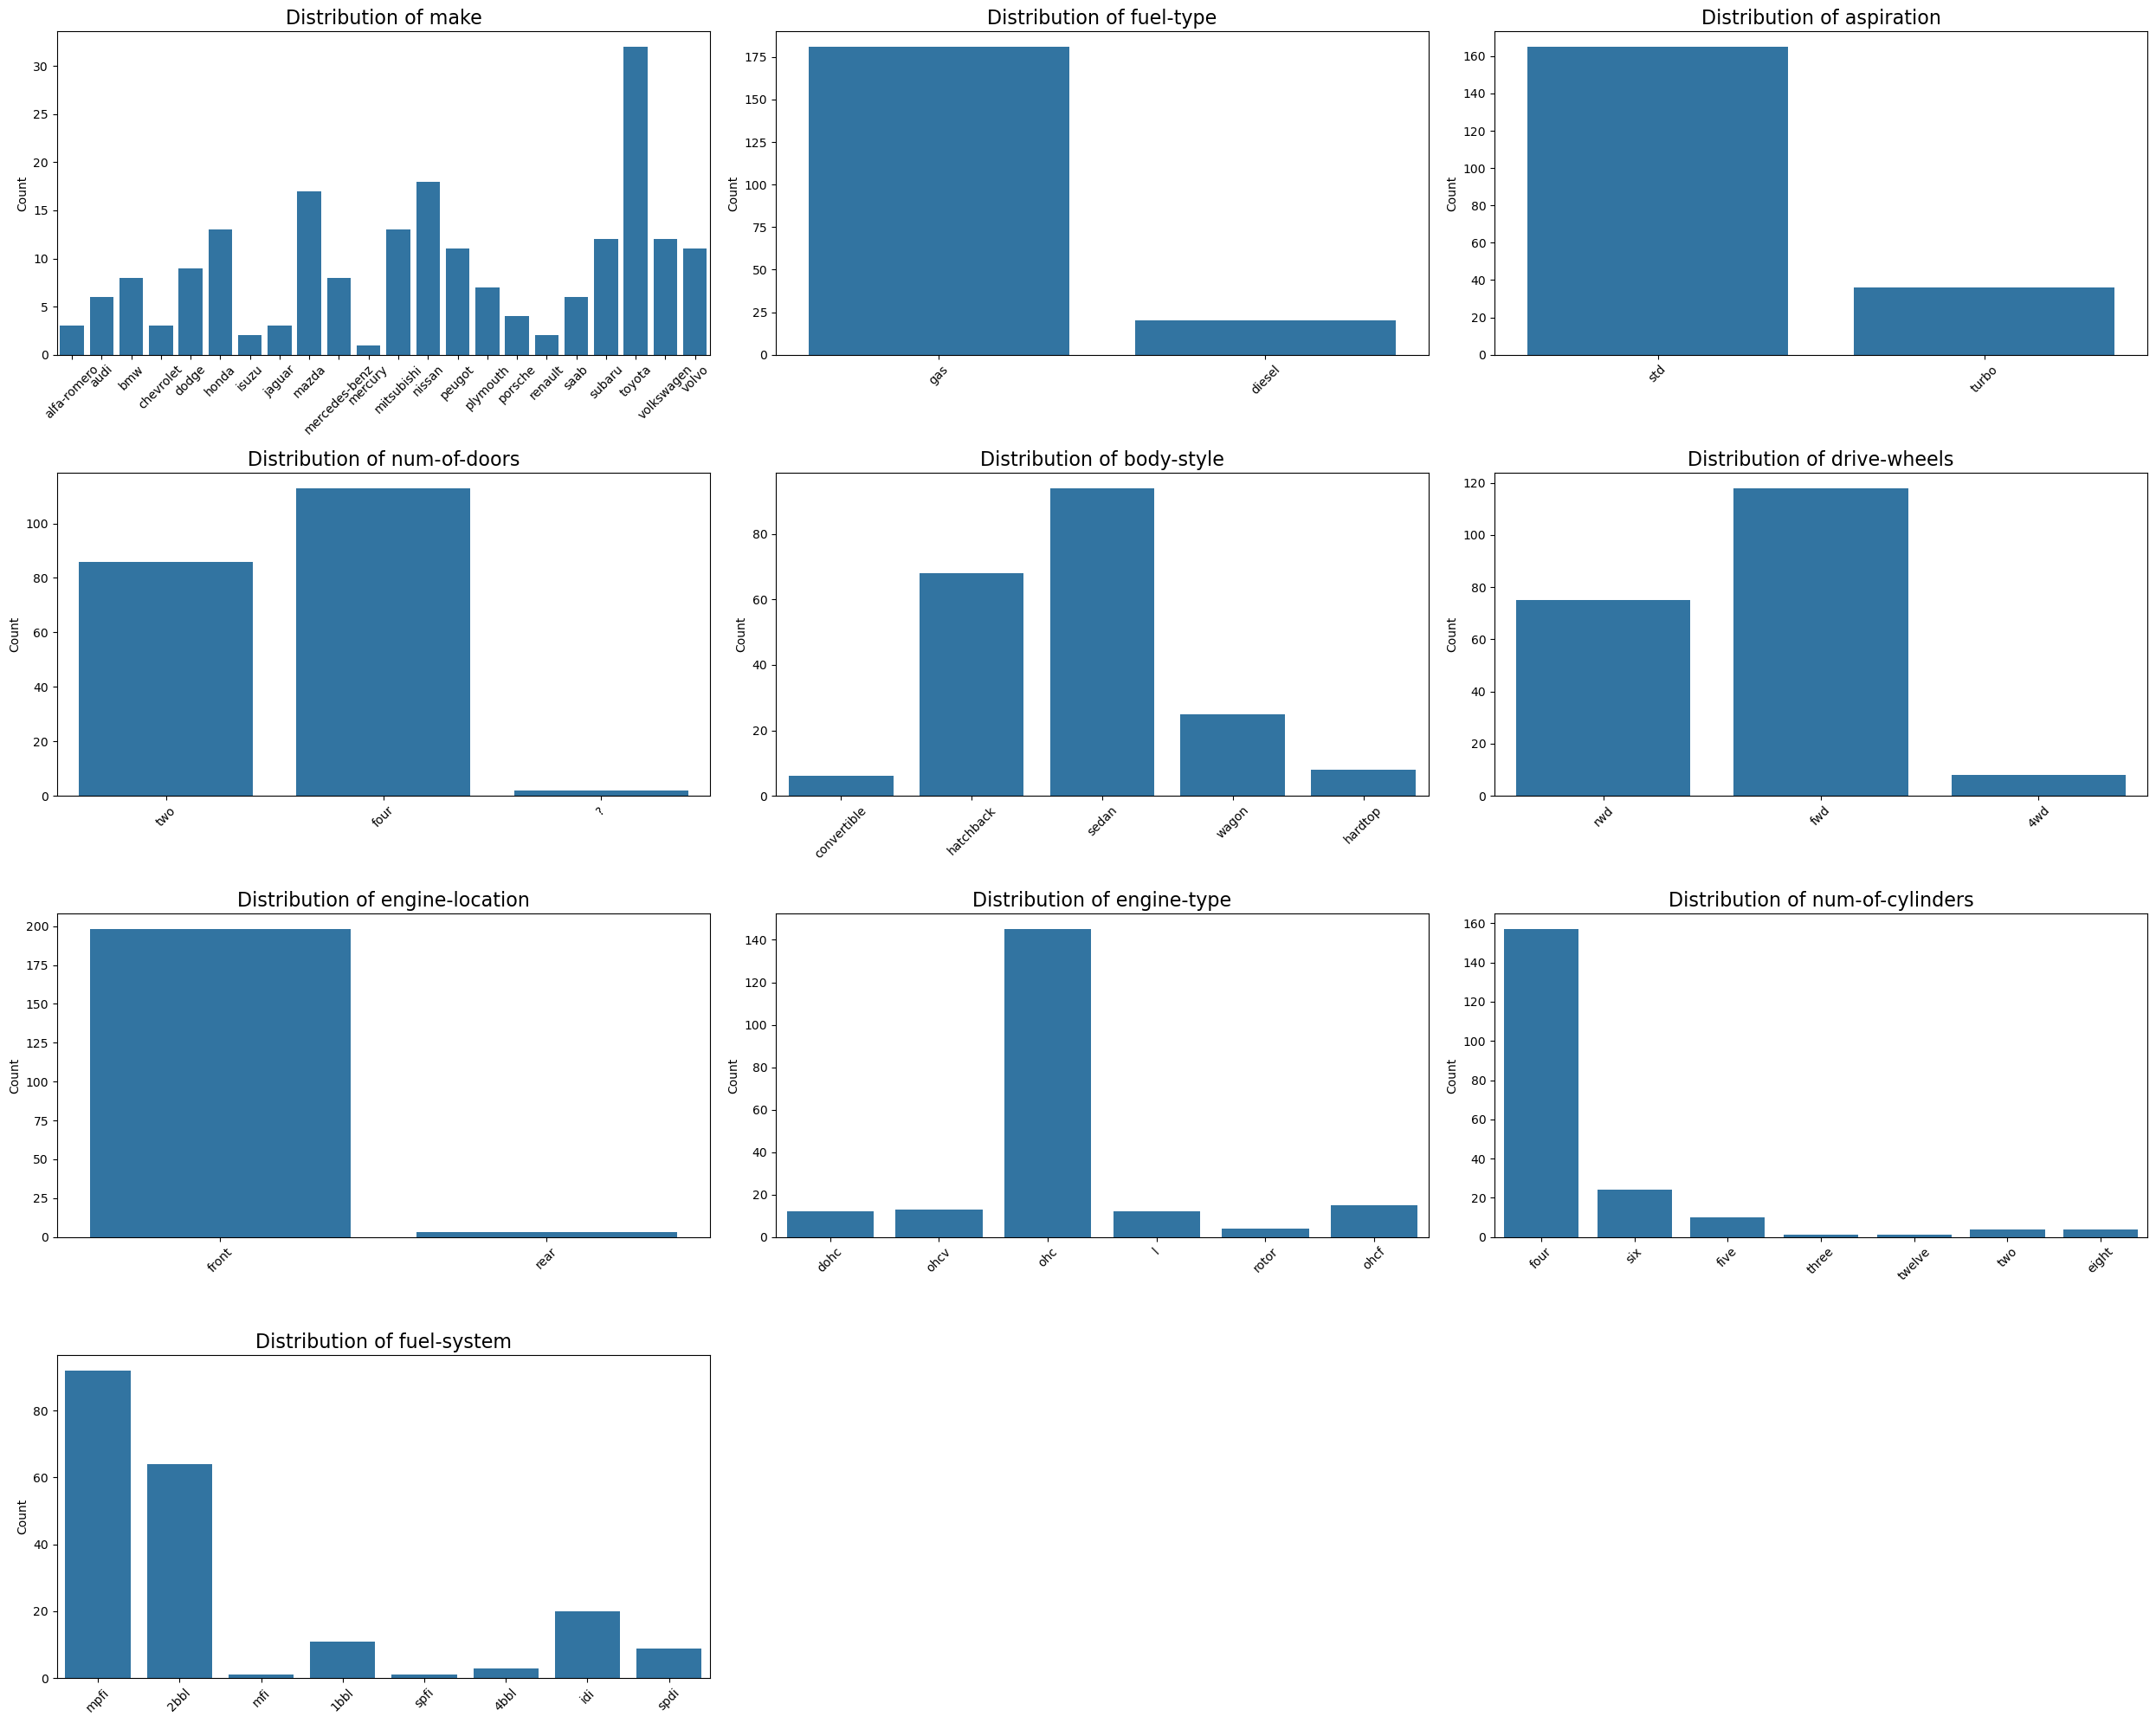

In [20]:
plt.figure(figsize=(25, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xticks(rotation=45) 
    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Insights**
  
- In make, a few car brands appear more frequently, while many brands have very few cars.
- Most cars use gas as fuel-type, and diesel cars are much fewer.
- In aspiration, the majority of cars are standard, and turbo cars are limited.
- Most cars have four doors, sedan body-style, and front-wheel drive, showing common market preference.
- Engine-location is mostly front, and engine types, cylinders, and fuel systems show that standard engine configurations are more common than advanced ones.

## **Bivariate Analysis**

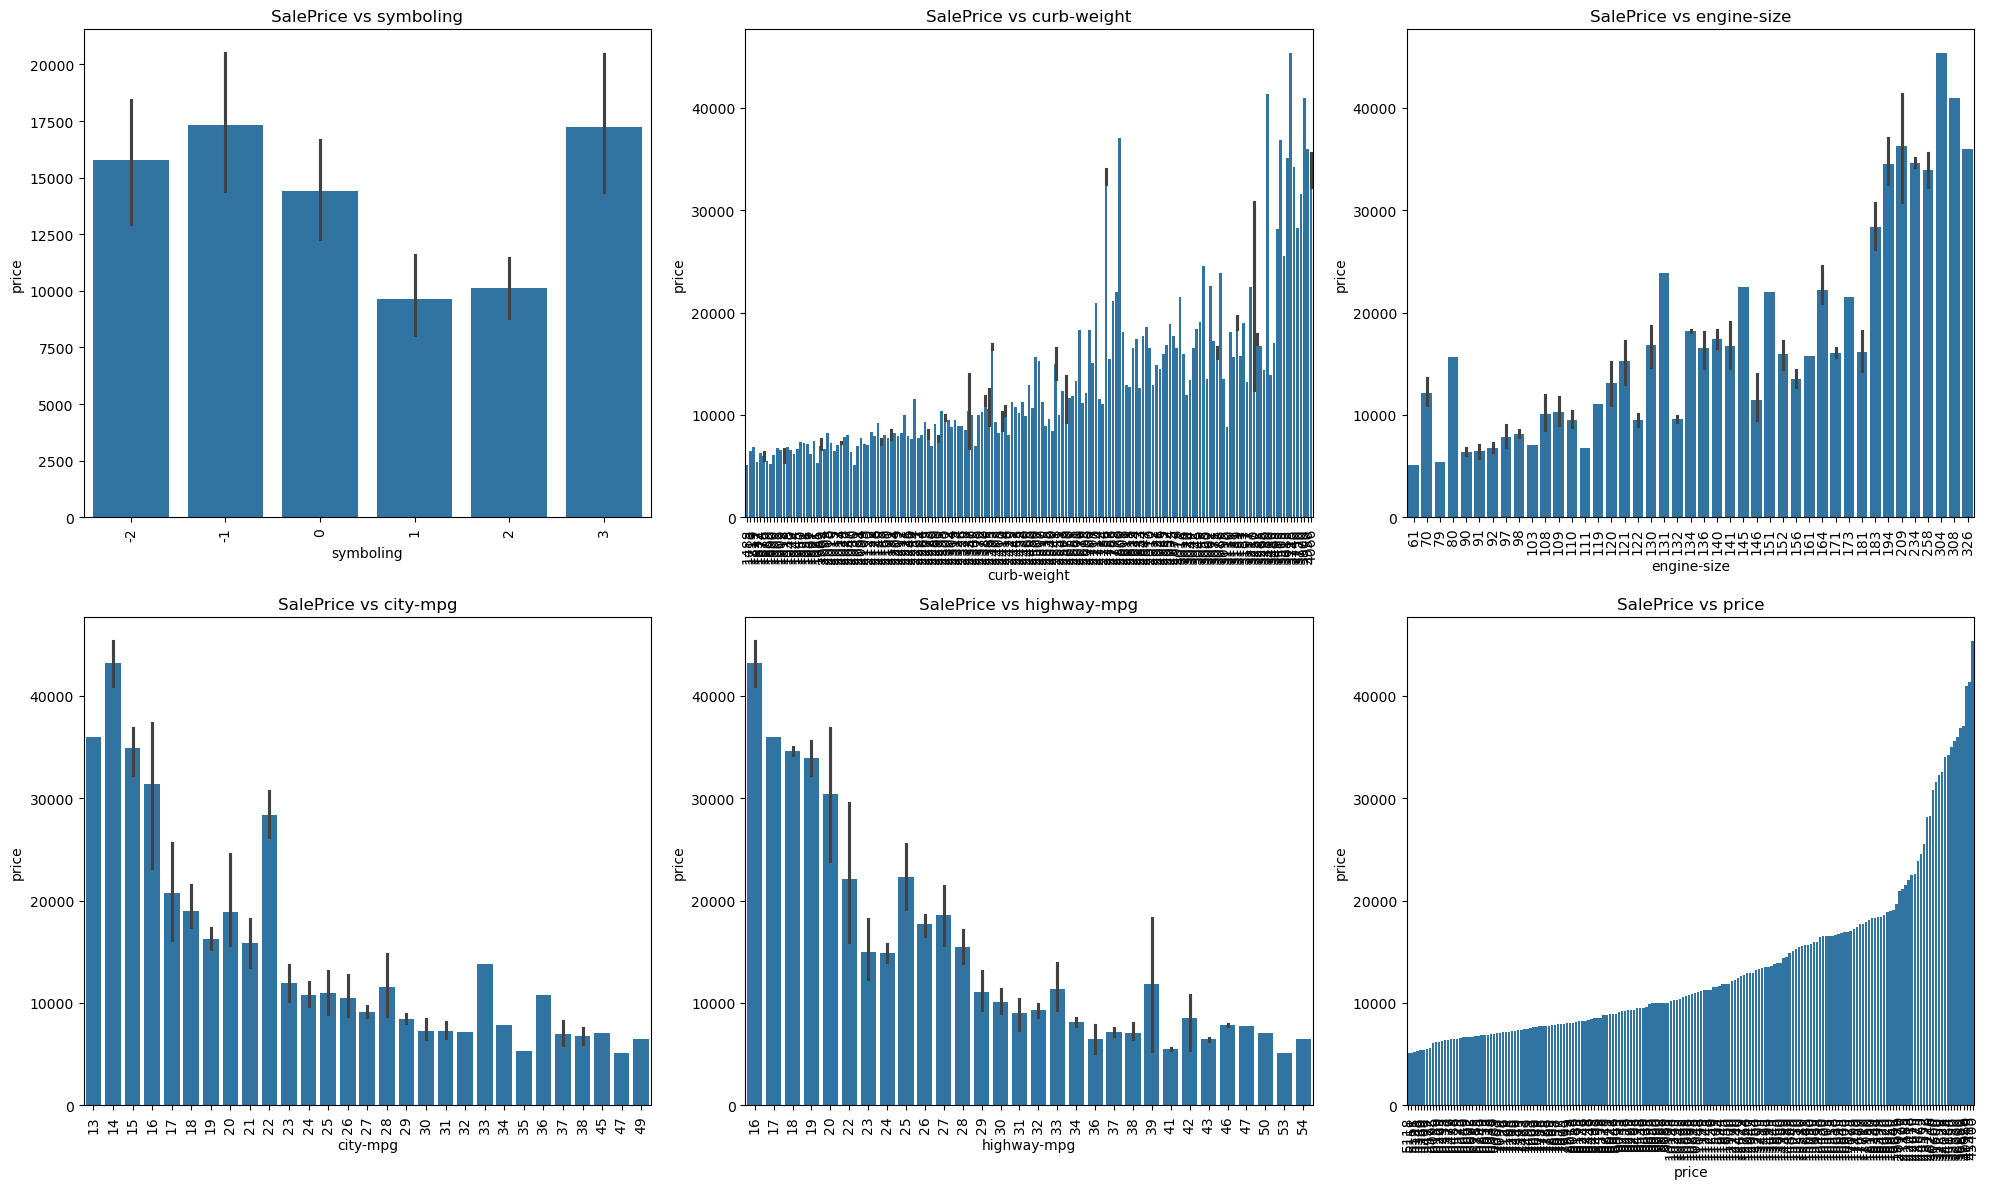

In [21]:
plt.figure(figsize=(20, 12))
plot = 1

for i in num_dis:
    plt.subplot(2, 3, plot)
    sns.barplot(x=i, y='price', data=df)
    plt.title(f"SalePrice vs {i}")
    plt.xticks(rotation=90)
    plot += 1

plt.tight_layout()
plt.show()

Insights 

- Engine-size and curb-weight show strong positive relation with price, meaning bigger engines and heavier cars cost more.
- City-mpg and highway-mpg show negative relation with price, which means fuel-efficient cars are usually cheaper.
- Symboling shows weak or no clear relation with price, so it may not be an important feature.
- Price increases clearly for high values of engine-size and curb-weight, showing these are important for prediction.
- Overall, engine-size and curb-weight are strong predictors, while mileage features have moderate impact and symboling has low impact

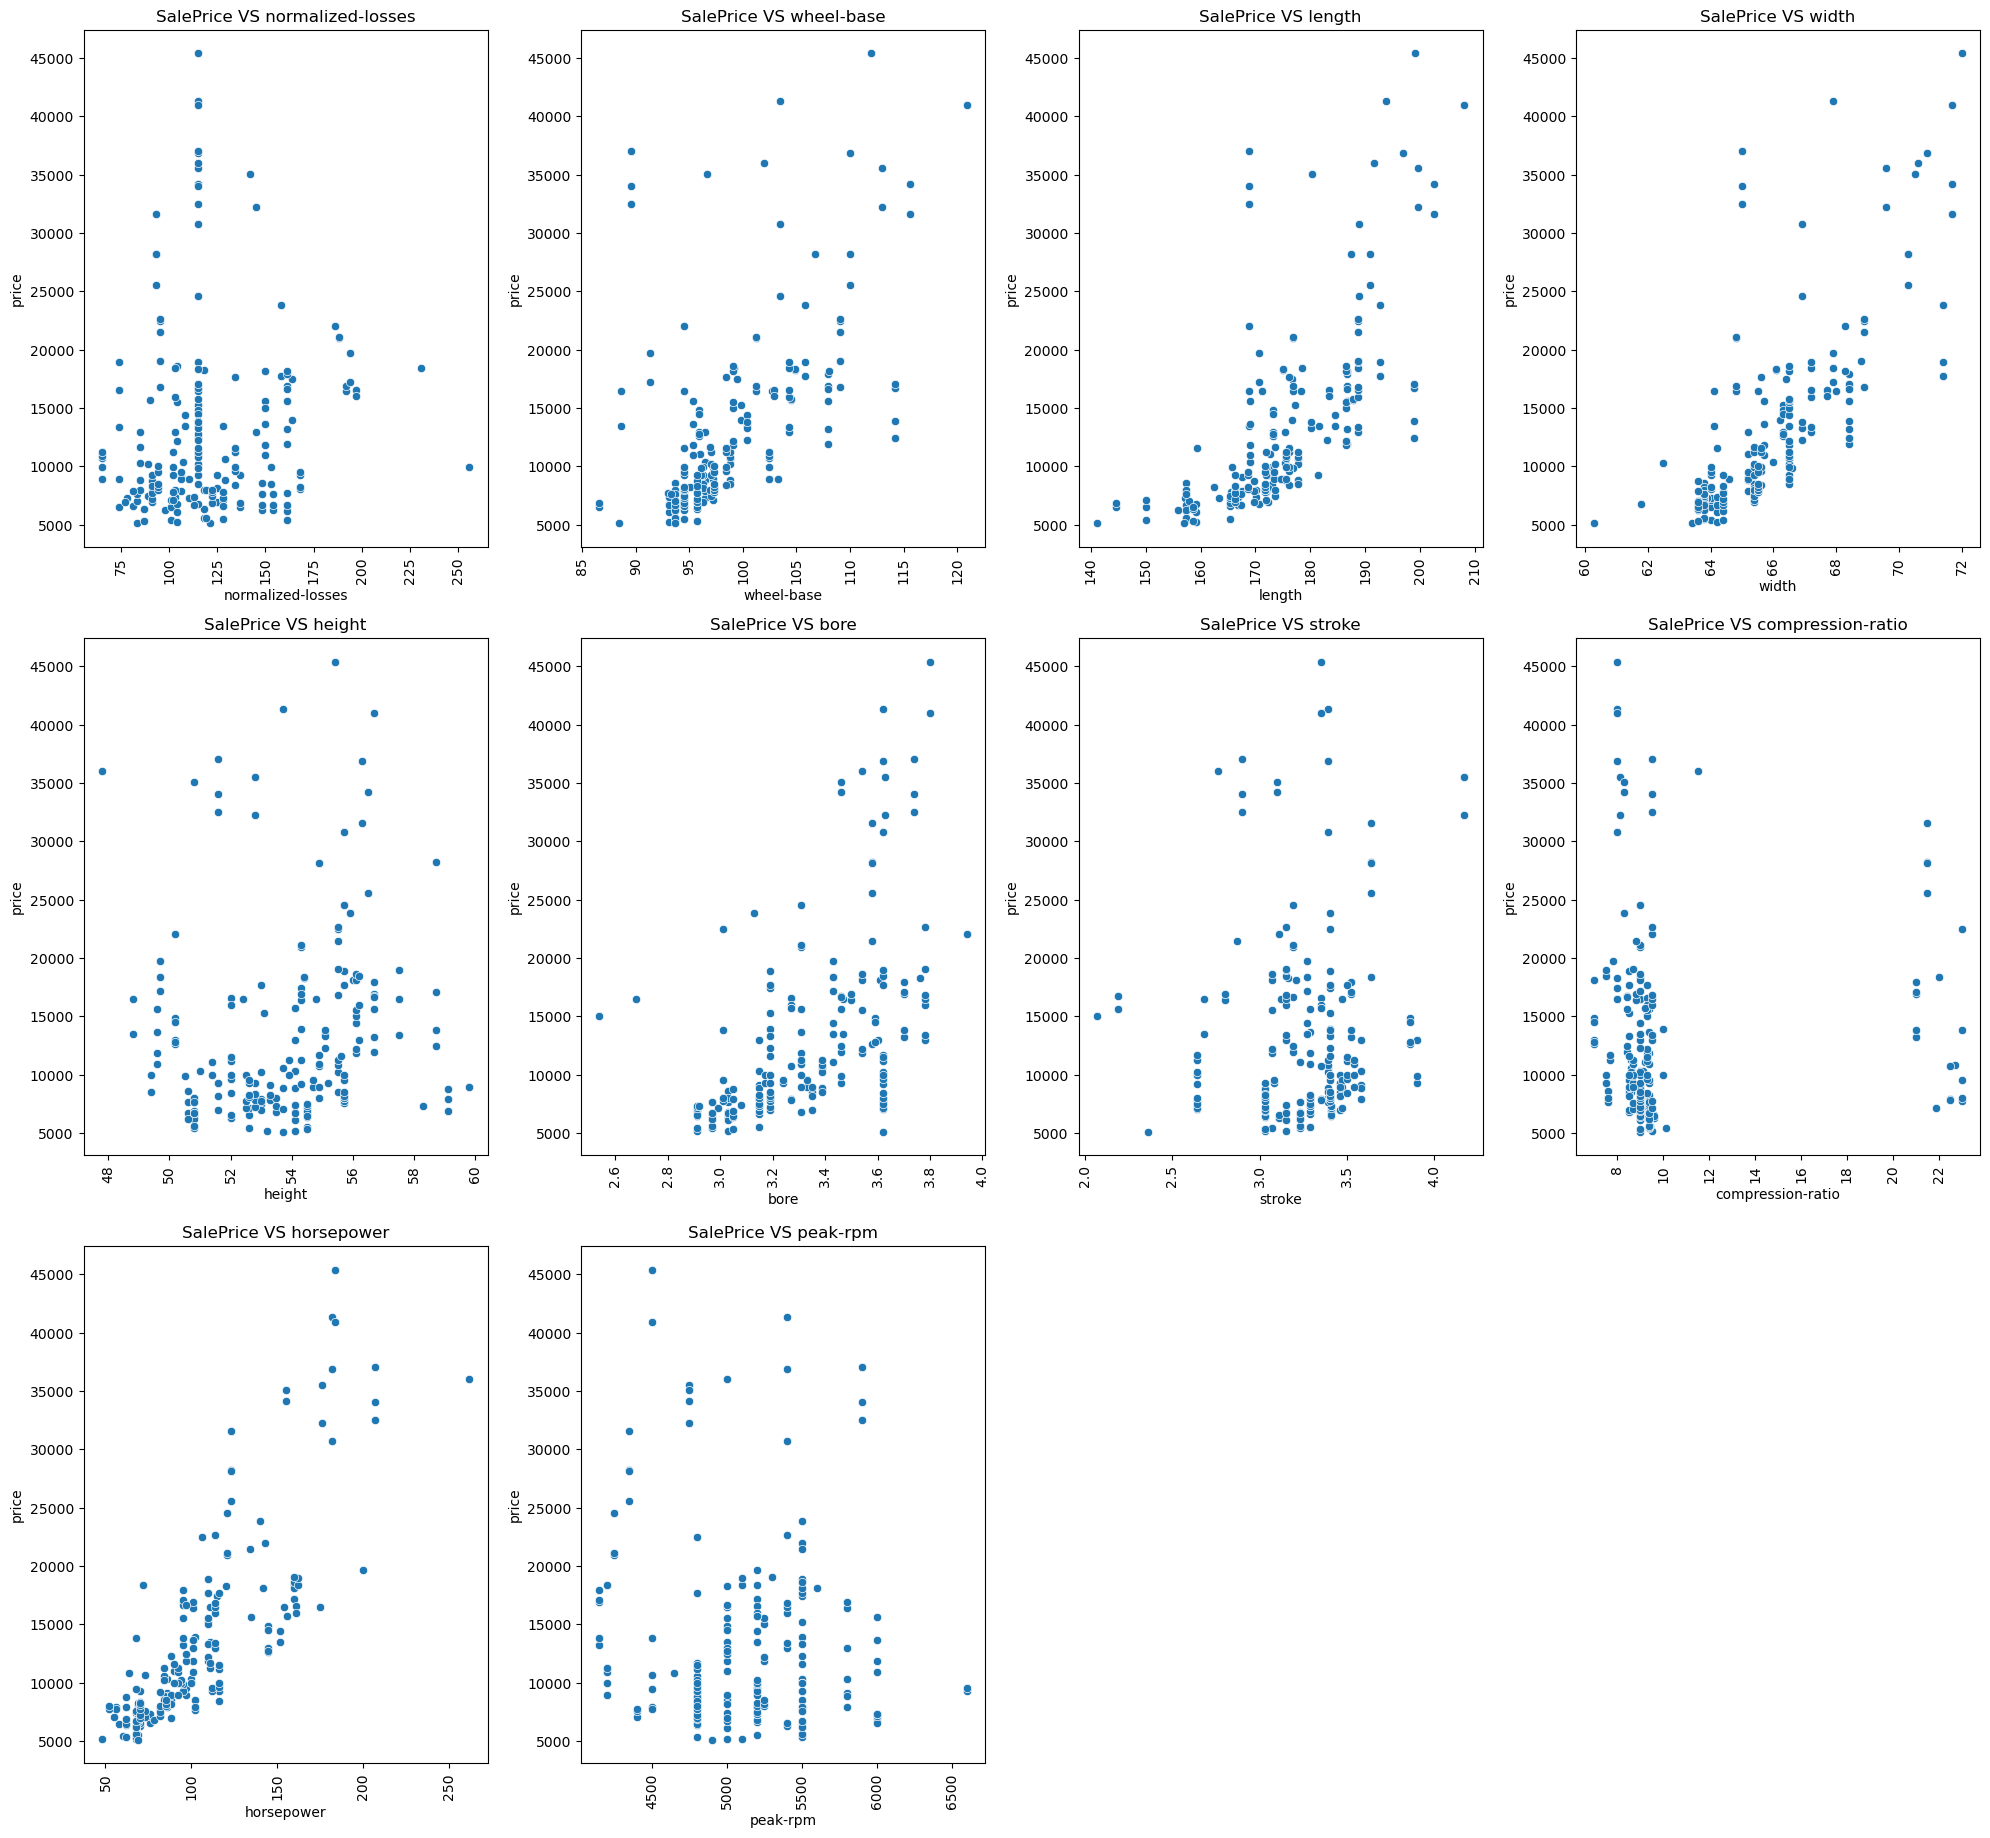

In [22]:
plt.figure(figsize=(20, 30))
plot = 1

for i in num_counti:   
        plt.subplot(5, 4, plot)
        sns.scatterplot(x=df[i], y=df['price'])   
        plt.title(f"SalePrice VS {i}")
        plt.xticks(rotation=90)       
        plot += 1

plt.tight_layout()
plt.show()

Insights

- Horsepower, width, and length show a strong positive relationship with price, meaning higher values increase car price.
- Wheel-base and bore show a moderate positive trend, so they have some effect on price.
- Normalized-losses, height, stroke, and peak-rpm show weak relationships and have less impact on price.
- Compression-ratio shows no clear pattern and contains outliers, so its effect is inconsistent.
- Overall, size and power-related features influence price more, while other features have low importance

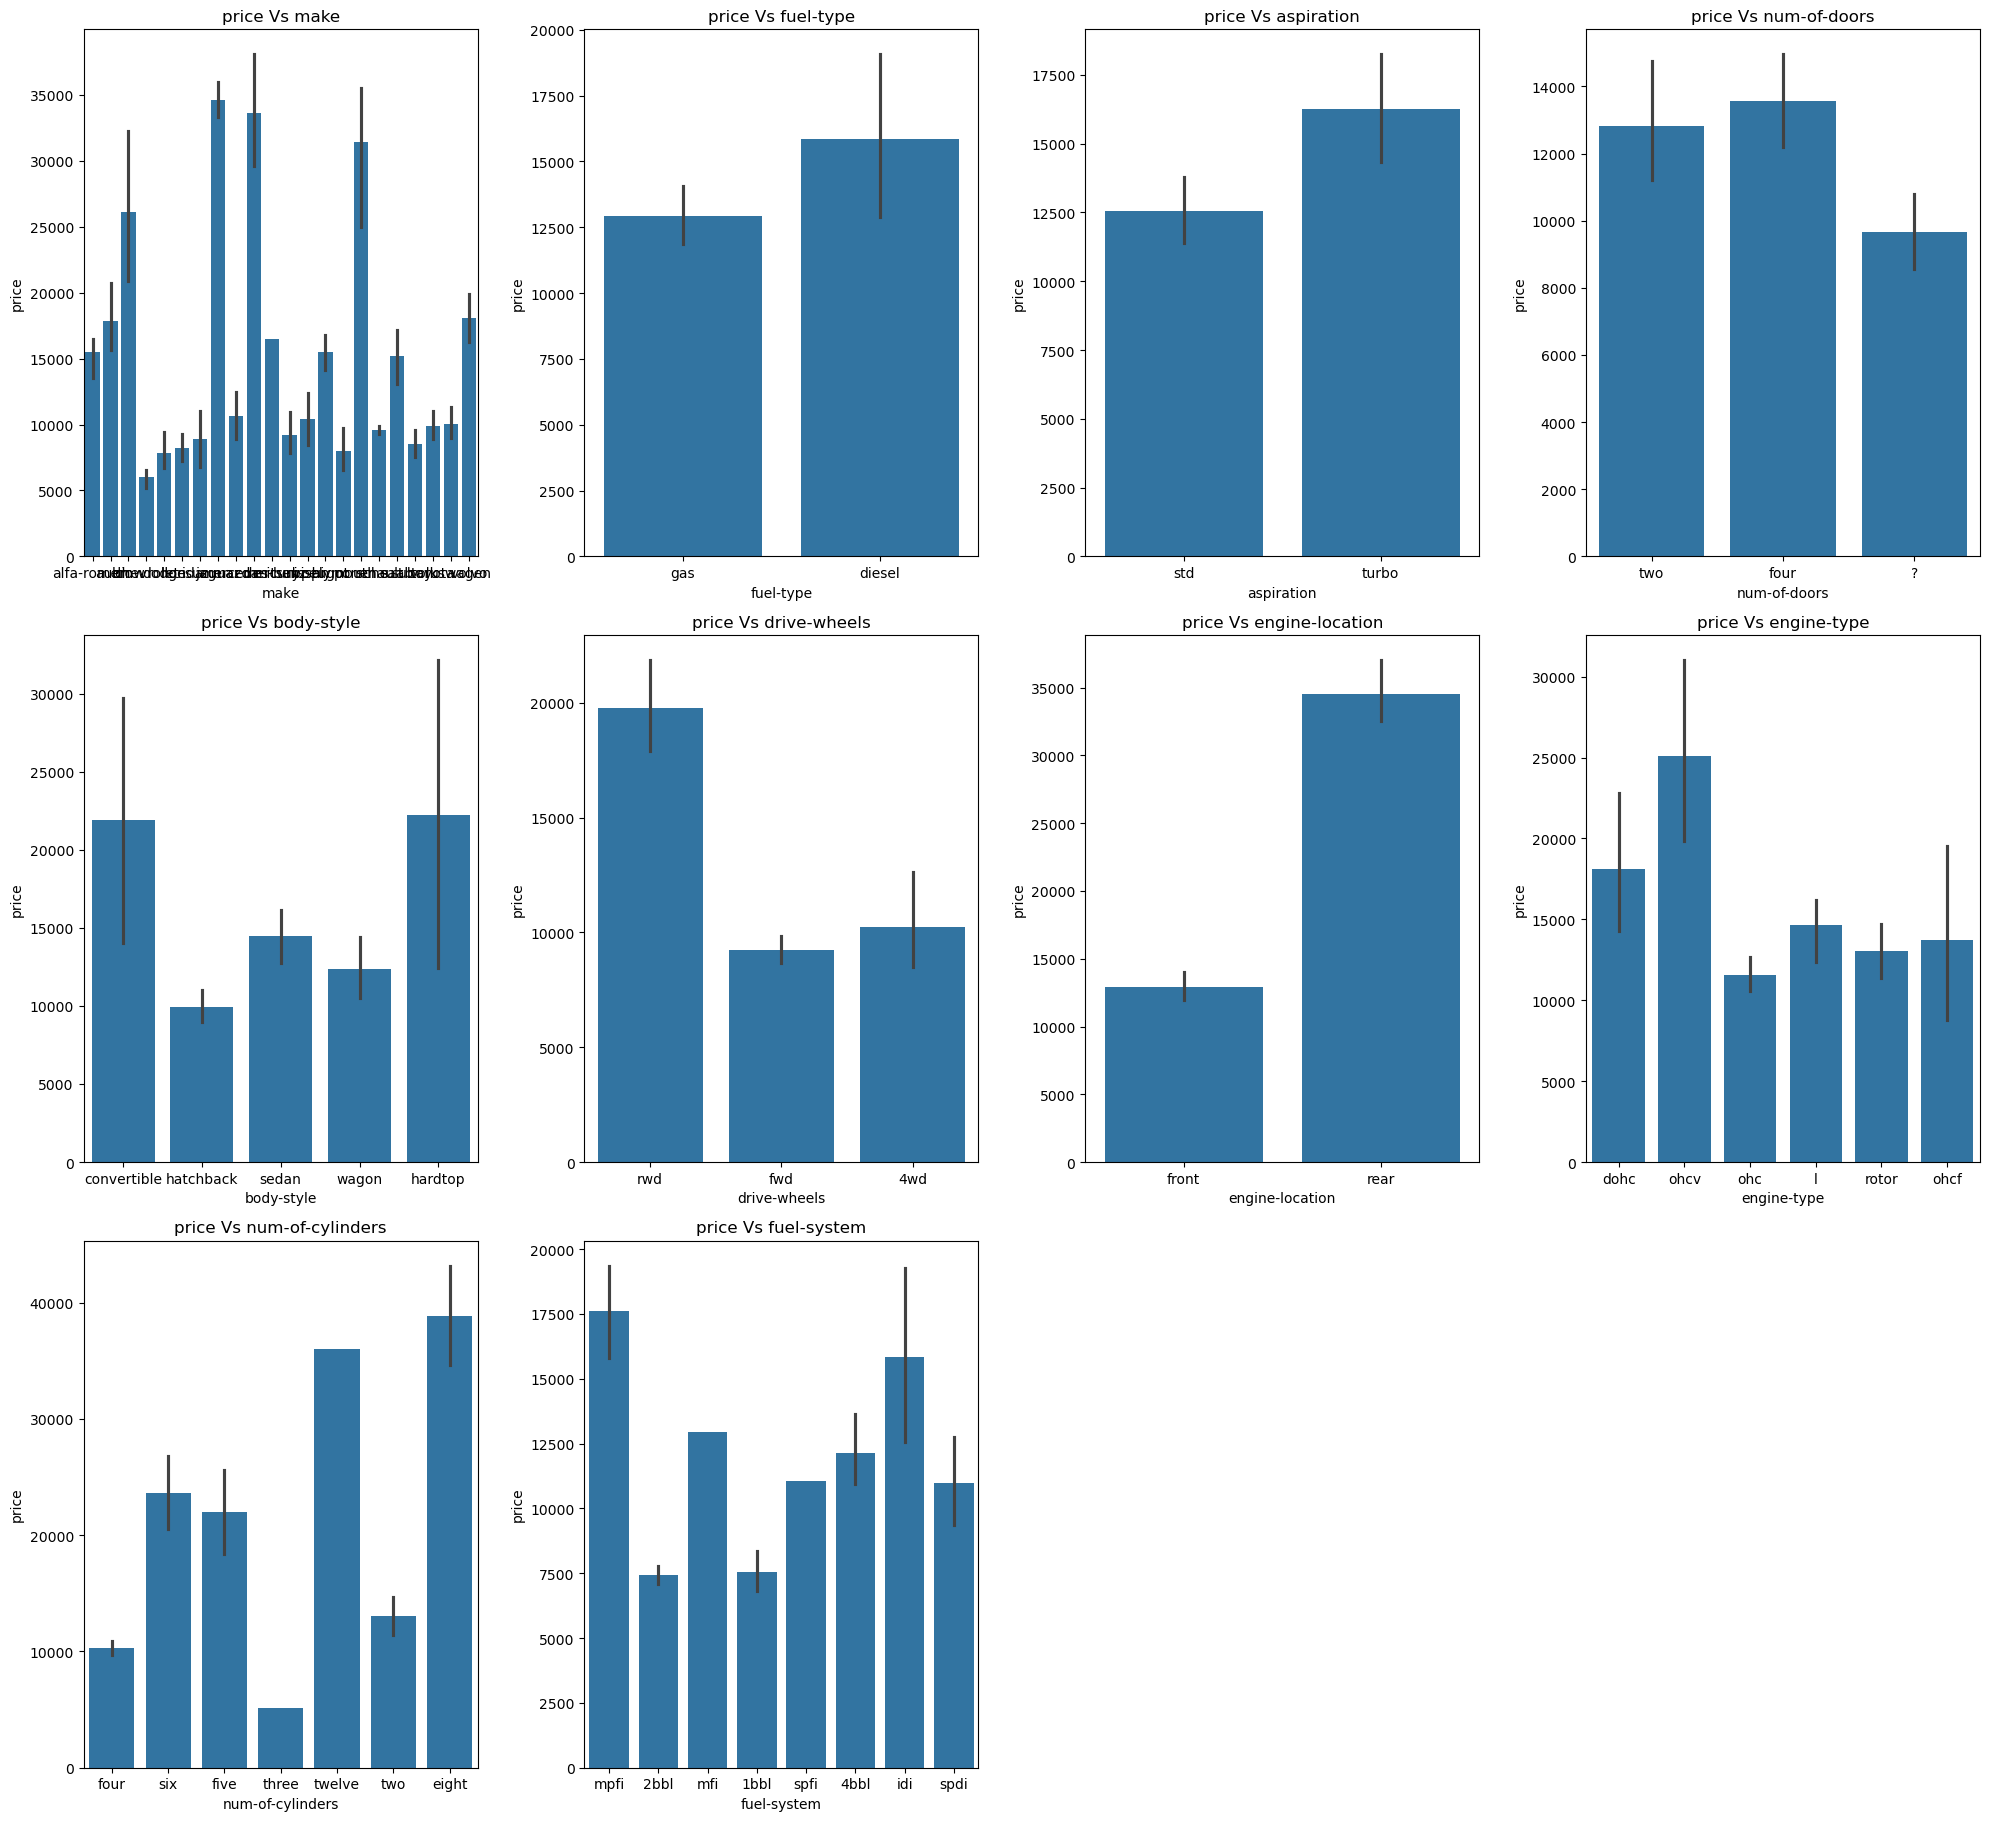

In [23]:
plt.figure(figsize=(20, 30))
plot = 1

for i in cat_cols: 
        plt.subplot(5, 4, plot)
        sns.barplot(x=i, y='price', data=df)
        plt.title(f"price Vs {i}")
        plot += 1

plt.tight_layout()
plt.show()

Insights 

- Car make has a strong impact on price, as luxury brands show higher average prices than normal brands.
- Fuel-type and aspiration show moderate effect, where diesel and turbo cars generally have higher prices.
- Body-style and drive-wheels affect price, as sedans/SUVs and rear-wheel drive cars tend to be more expensive.
- Engine features like engine-type and number of cylinders show strong impact, because cars with more cylinders have higher prices.
- Engine-location and fuel-system show some variation, but their impact is smaller compared to brand and engine size.

## Multivariant Analysis

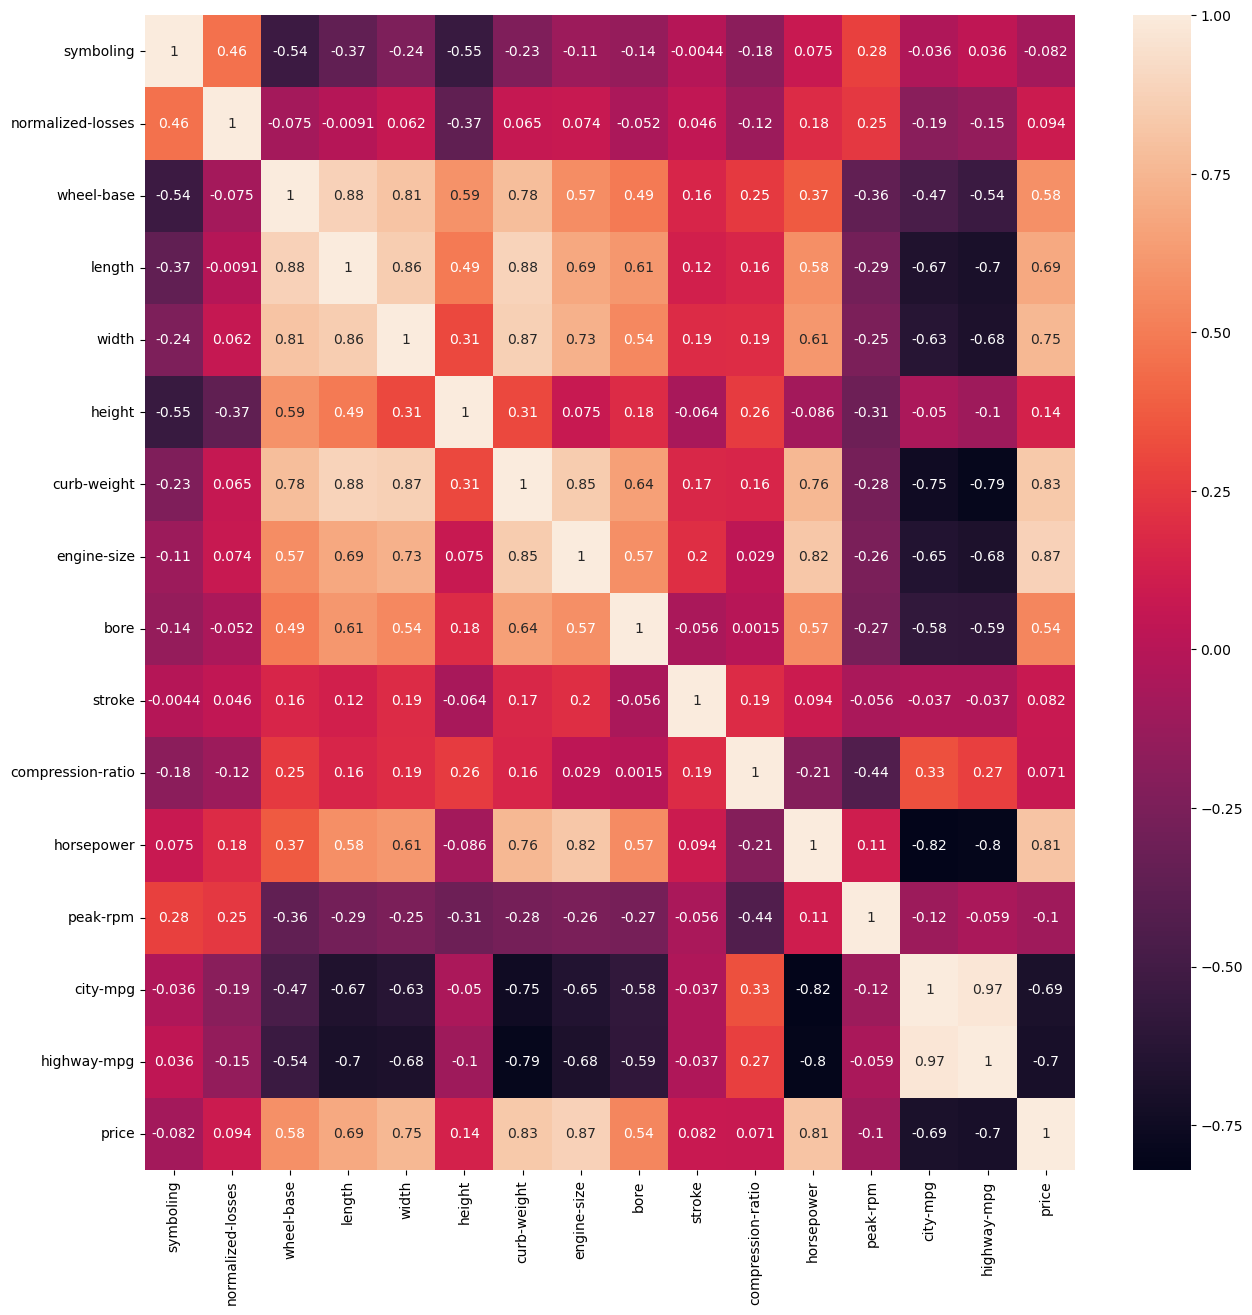

In [24]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True)
plt.show()

insights

- Increases in engine capacity, weight, width, length, and wheel base result in higher prices.
- When fuel efficiency (mpg) rises, prices fall.
- The best indicators of price:
   - Engine dimensions
   - Curb-weight
   - The width
   - Length
- The least significant factors are height, compression ratio, and symbolism.

# Feature engineering 

## Null Value Handling

In [25]:
(df == "?").sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

##  Outliers Handling

In [26]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [27]:
num_cols = num_cols.drop('price')

In [28]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

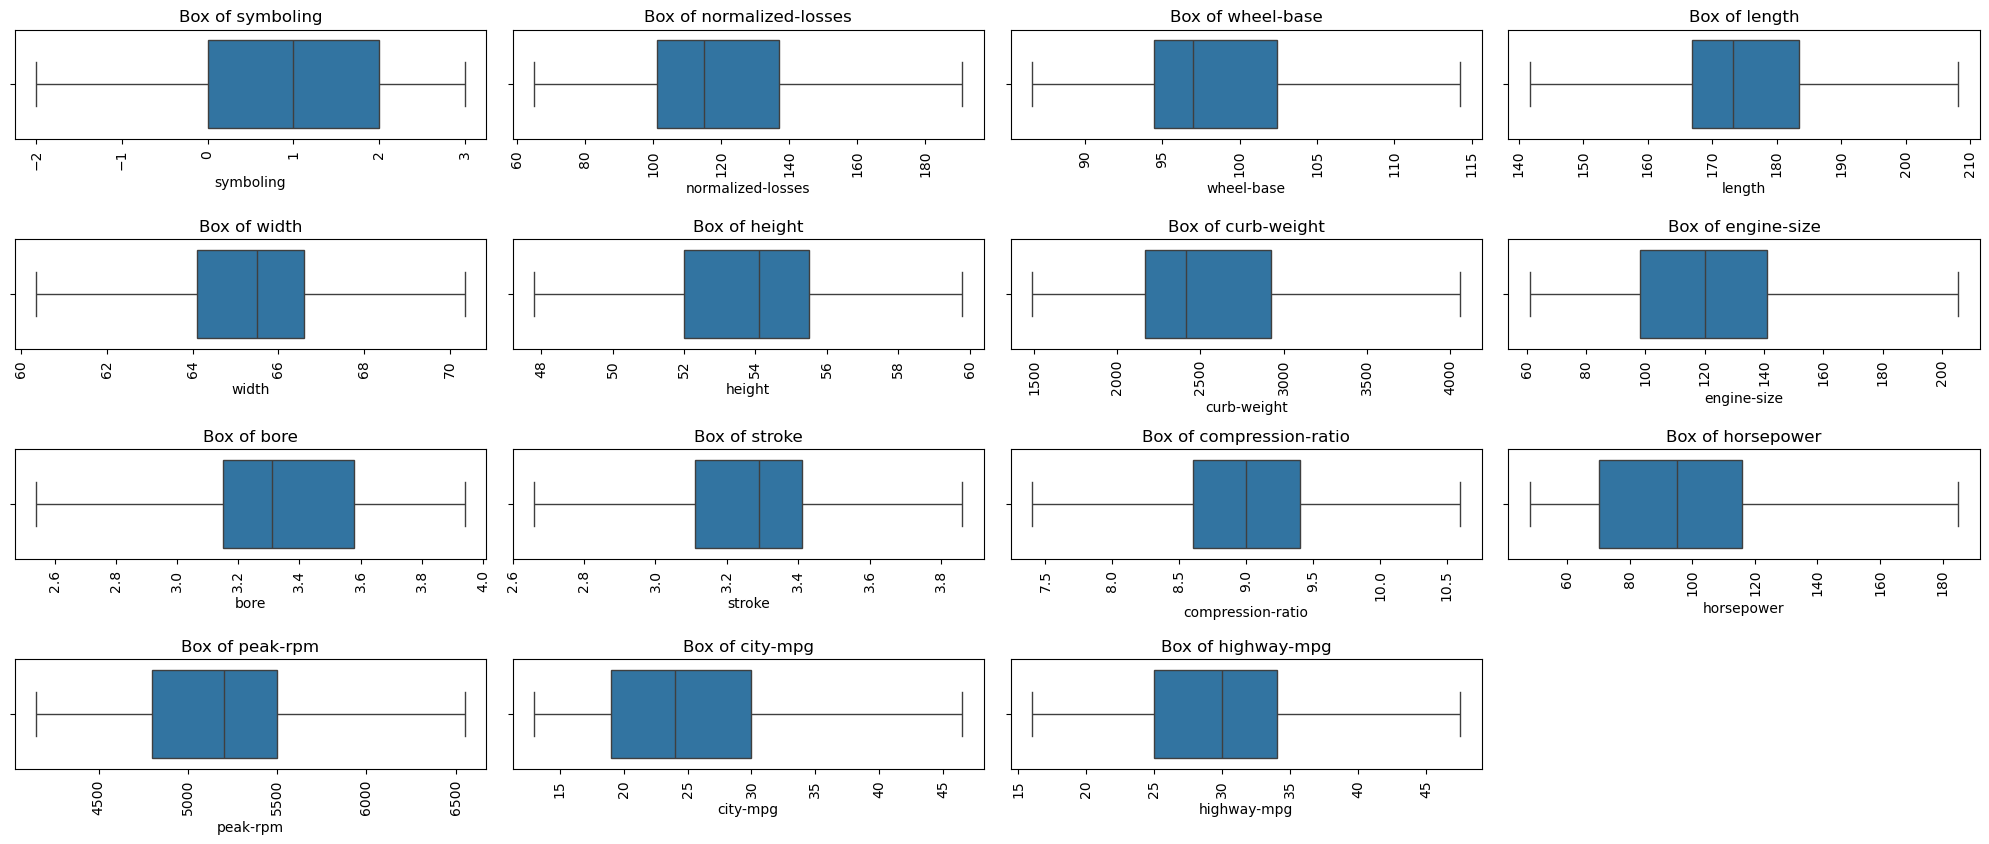

In [29]:
plt.figure(figsize=(20, 10))
plot = 1

for i in num_cols:   
        plt.subplot(5, 4, plot)
        sns.boxplot(x=i, data=df)   
        plt.title(f"Box of {i}")
        plt.xticks(rotation=90)       
        plot += 1

plt.tight_layout()
plt.show()

## Encoding 

In [30]:
cat_cols

Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')

In [31]:
label_encode_cols = ['fuel-type','aspiration','engine-location']
ordinal_encode_cols = ['num-of-doors','num-of-cylinders']
onehot_encode_cols = ['body-style','drive-wheels','engine-type','fuel-system']

In [32]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

### Label Encoding

In [33]:
le = LabelEncoder()

for col in label_encode_cols:
    df[col] = le.fit_transform(df[col])

### Ordinal Encoding

In [34]:
df[ordinal_encode_cols] = df[ordinal_encode_cols].replace('?', np.nan)

In [35]:
for col in ordinal_encode_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [36]:
ordinal_categories = [
    ['two', 'four'],                                            # num-of-doors
    ['two', 'three', 'four', 'five', 'six', 'eight', 'twelve']  # num-of-cylinders
]

oe = OrdinalEncoder(categories=ordinal_categories)

df[ordinal_encode_cols] = oe.fit_transform(df[ordinal_encode_cols])

### One-Hot Encoding

In [37]:
existing_ohe_cols = [col for col in onehot_encode_cols if col in df.columns]

df = pd.get_dummies(df, columns=existing_ohe_cols, drop_first=True, dtype='int64')

In [38]:
### Target encoding

In [39]:
df["make"].value_counts()

make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              6
saab              6
porsche           4
chevrolet         3
alfa-romero       3
jaguar            3
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64

In [40]:
# Calculate global mean
global_mean = df['price'].mean()

In [41]:
# Compute mean price per category (make)
make_mean = df.groupby('make')['price'].mean()

In [42]:
# Map encoded values
df['make_encoded'] = df['make'].map(make_mean)

In [43]:
df['make_encoded'].fillna(global_mean, inplace=True)

In [44]:
# Drop original column
df.drop('make', axis=1, inplace=True)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   symboling             201 non-null    int64  
 1   normalized-losses     201 non-null    float64
 2   fuel-type             201 non-null    int64  
 3   aspiration            201 non-null    int64  
 4   num-of-doors          201 non-null    float64
 5   engine-location       201 non-null    int64  
 6   wheel-base            201 non-null    float64
 7   length                201 non-null    float64
 8   width                 201 non-null    float64
 9   height                201 non-null    float64
 10  curb-weight           201 non-null    float64
 11  num-of-cylinders      201 non-null    float64
 12  engine-size           201 non-null    float64
 13  bore                  201 non-null    float64
 14  stroke                201 non-null    float64
 15  compression-ratio     2

In [46]:
df.shape

(201, 40)

Encoding:

- High-cardinality feature make was target encoded to capture brand-level price influence while avoiding dimensionality explosion caused by one-hot encoding.

- Binary categorical features (fuel-type, aspiration, engine-location) were label encoded, as they contain only two categories and do not require ordinal ranking.

- Ordinal features (num-of-doors, num-of-cylinders) were ordinal encoded using domain-driven ordering, preserving real-world magnitude relationships relevant for price prediction.

- Nominal low-cardinality features (body-style, drive-wheels, engine-type, fuel-system) were one-hot encoded, ensuring no artificial ordering was introduced while keeping dimensionality manageable.

- All encoded outputs were converted to numeric (int/float) formats, making the dataset fully compatible with regression models and feature scaling techniques.

## Feature Selection

In [47]:
corr_matrix = df.corr()

In [48]:
corr_matrix

,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,engine-location,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_fwd,drive-wheels_rwd,engine-type_l,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi,make_encoded
symboling,1.000000,0.461856,0.196735,-0.054615,-0.672344,0.212339,-0.541604,-0.365417,-0.245915,-0.550160,-0.233119,-0.125574,-0.106239,-0.142547,0.011440,-0.077370,0.067952,0.280660,-0.037995,0.028759,-0.082391,0.168221,0.443787,-0.382656,-0.301347,0.103220,-0.082676,-0.135710,-0.079045,0.036120,-0.015035,0.245809,-0.032515,0.212339,-0.196735,0.121979,0.013138,0.181292,0.065487,-0.127092
normalized-losses,0.461856,1.000000,0.105741,-0.003109,-0.354006,-0.020782,-0.072448,-0.005859,0.069413,-0.370687,0.066325,0.092615,0.088826,-0.052318,0.055826,-0.083024,0.193081,0.249729,-0.197423,-0.157162,0.098746,0.039917,0.193908,-0.008077,-0.297171,-0.226443,0.287759,0.185926,-0.158656,-0.219392,0.112617,0.141381,-0.117873,0.122130,-0.105741,0.058430,0.170518,0.059206,-0.011938,0.097430
fuel-type,0.196735,0.105741,1.000000,-0.408228,-0.186681,0.040917,-0.313348,-0.211248,-0.256345,-0.281578,-0.221131,0.008881,-0.112233,-0.054944,-0.264622,-0.661097,0.171826,0.477437,-0.268648,-0.202384,-0.110326,-0.017342,0.202558,-0.188099,-0.025808,0.092537,-0.121562,-0.266984,-0.021211,0.094398,0.087411,0.047367,0.227198,0.040917,-1.000000,0.023505,0.305391,0.071969,0.023505,-0.158973
aspiration,-0.054615,-0.003109,-0.408228,1.000000,0.063017,-0.057496,0.263698,0.230123,0.320438,0.090336,0.322078,-0.039163,0.170833,0.228489,0.235255,-0.116039,0.273810,-0.190878,-0.189701,-0.244478,0.179578,-0.028728,-0.004912,0.030274,0.020539,-0.135303,0.122527,0.210876,-0.028078,-0.033899,-0.070076,-0.066559,-0.319256,-0.057496,0.408228,0.151383,-0.064525,0.400774,-0.033029,0.109570
num-of-doors,-0.672344,-0.354006,-0.186681,0.063017,1.000000,-0.142340,0.449006,0.395095,0.230741,0.538383,0.208495,0.032294,0.041811,0.120915,-0.022022,0.048038,-0.083281,-0.231781,-0.025129,-0.034589,0.042435,-0.235432,-0.614324,0.528393,0.325922,0.030380,-0.081303,0.175461,0.023322,0.015991,-0.058783,-0.164777,0.008269,-0.142340,0.186681,-0.081768,0.047697,-0.153121,-0.081768,0.058697
engine-location,0.212339,-0.020782,0.040917,-0.057496,-0.142340,1.000000,-0.192634,-0.053156,-0.052425,-0.109225,0.051311,0.235791,0.256320,0.188583,-0.161123,0.072526,0.290279,0.202470,-0.158139,-0.104912,0.331062,0.394707,-0.088015,-0.115372,-0.046392,-0.146768,0.159545,-0.031016,-0.198070,0.433450,-0.032368,-0.017540,-0.084131,-0.015152,-0.040917,-0.008704,0.133982,-0.026650,-0.008704,0.316663
wheel-base,-0.541604,-0.072448,-0.313348,0.263698,0.449006,-0.192634,1.000000,0.876280,0.813860,0.595586,0.780782,0.349523,0.558555,0.494346,0.182825,0.018210,0.402278,-0.359945,-0.468984,-0.539633,0.573278,-0.008628,-0.401032,0.301282,0.217138,-0.461656,0.501490,0.410633,-0.197640,-0.187872,0.143534,-0.083180,-0.396090,-0.071854,0.313348,-0.034099,0.348446,-0.120280,-0.032903,0.542787
length,-0.365417,-0.005859,-0.211248,0.230123,0.395095,-0.053156,0.876280,1.000000,0.860803,0.492347,0.880783,0.456054,0.705506,0.609572,0.143064,-0.052155,0.605978,-0.285957,-0.664495,-0.695930,0.690846,0.045305,-0.460267,0.293221,0.217851,-0.504825,0.538330,0.262926,-0.271510,-0.123405,0.243806,-0.060375,-0.475874,-0.052154,0.211248,-0.005781,0.506349,-0.083508,-0.009235,0.616253
width,-0.245915,0.069413,-0.256345,0.320438,0.230741,-0.052425,0.813860,0.860803,1.000000,0.304839,0.874482,0.499463,0.732845,0.563132,0.213728,-0.032760,0.637223,-0.249153,-0.642562,-0.687819,0.738159,0.058358,-0.266441,0.191173,0.071318,-0.474031,0.522844,0.240067,-0.275131,-0.126704,0.342564,-0.010148,-0.531088,

### Correlation with target

In [49]:
price_corr = corr_matrix['price'].sort_values(ascending=False)
price_corr

price                   1.000000
make_encoded            0.892113
engine-size             0.849061
curb-weight             0.834400
horsepower              0.805532
width                   0.738159
num-of-cylinders        0.716578
length                  0.690846
drive-wheels_rwd        0.637522
wheel-base              0.573278
bore                    0.543158
fuel-system_mpfi        0.509698
engine-type_ohcv        0.394454
engine-location         0.331062
body-style_hardtop      0.231180
aspiration              0.179578
body-style_sedan        0.148105
height                  0.135486
fuel-system_idi         0.110326
normalized-losses       0.098746
stroke                  0.065933
engine-type_l           0.045151
num-of-doors            0.042435
engine-type_ohcf        0.019039
fuel-system_mfi        -0.002169
engine-type_rotor      -0.003364
fuel-system_4bbl       -0.016492
fuel-system_spfi       -0.019259
body-style_wagon       -0.039707
fuel-system_spdi       -0.060541
symboling 

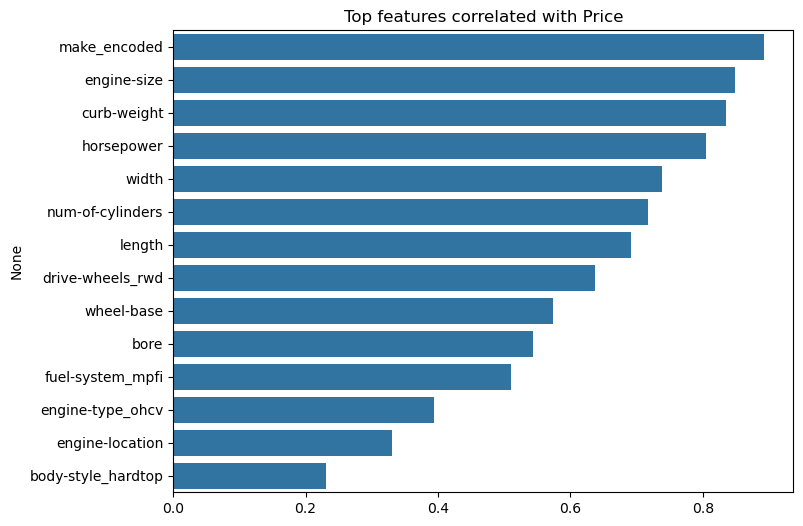

In [50]:
top_corr = price_corr[1:15]

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top features correlated with Price")
plt.show()

Insights

- Engine size has the strongest positive relation with price. Bigger engine cars are more expensive.
- Curb weight and horsepower are highly related to price. Heavy and powerful cars cost more.
- Width, number of cylinders, and car length also increase the price. Bigger size cars usually have higher price.
- Wheel base and rear-wheel drive have a medium effect on price. These features slightly increase the car cost.
- Fuel system, engine type, body style, and engine location have low correlation with price. These features do not affect the price much.

In [51]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

high_corr

['length',
 'width',
 'curb-weight',
 'engine-size',
 'highway-mpg',
 'fuel-system_4bbl',
 'make_encoded']

### Droping Columns

In [52]:
drop_cols = ['num-of-cylinders','horsepower','length','wheel-base','bore']
df = df.drop(columns=drop_cols)

- Features showing high multicollinearity were removed using an upper-triangle correlation threshold of 0.85. In each correlated pair, the feature with lower correlation to the target variable was dropped to reduce redundancy and improve model stability.

# Modeling 

In [53]:
X = df.drop("price",axis=1)
y = df.price

In [54]:
X

,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,engine-location,width,height,curb-weight,engine-size,stroke,compression-ratio,peak-rpm,city-mpg,highway-mpg,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_fwd,drive-wheels_rwd,engine-type_l,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi,make_encoded
0,3,115.0,1,0,0.0,0,64.1,48.8,2548.0,130.0,2.68,9.0,5000.0,21.0,27.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,15498.333333
1,3,115.0,1,0,0.0,0,64.1,48.8,2548.0,130.0,2.68,9.0,5000.0,21.0,27.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,15498.333333
2,1,115.0,1,0,0.0,0,65.5,52.4,2823.0,152.0,3.47,9.0,5000.0,19.0,26.0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,15498.333333
3,2,164.0,1,0,1.0,0,66.2,54.3,2337.0,109.0,3.40,10.0,5500.0,24.0,30.0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,17859.166667
4,2,164.0,1,0,1.0,0,66.4,54.3,2824.0,136.0,3.40,8.0,5500.0,18.0,22.0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,17859.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95.0,1,0,1.0,0,68.9,55.5,2952.0,141.0,3.15,9.5,5400.0,23.0,28.0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,18063.181818
197,-1,95.0,1,1,1.0,0,68.8,55.5,3049.0,141.0,3.15,8.7,5300.0,19.0,25.0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,18063.181818
198,-1,95.0,1,0,1.0,0,68.9,55.5,3012.0,173.0,2.87,8.8,5500.0,18.0,23.0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,18063.181818
199,-1,95.0,0,1,1.0,0,68.9,55.5,3217.0,145.0,3.40,10.6,4800.0,26.0,27.0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,18063.181818


In [55]:
y

0      13495
1      16500
2      16500
3      13950
4      17450
       ...  
196    16845
197    19045
198    21485
199    22470
200    22625
Name: price, Length: 201, dtype: int64

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Scaling

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [58]:
X_train_scaled

array([[-0.64163177, -0.45737143,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.36776213],
       [ 0.18248243, -0.62830576,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.73379224],
       [-0.64163177,  2.34595159,  0.31994094, ..., -0.21160368,
        -0.08481889,  2.20860157],
       ...,
       [ 0.18248243,  0.29473962,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.36776213],
       [ 1.00659663,  0.08961843,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.42324425],
       [ 1.83071083,  2.44851218,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.36776213]])

In [59]:
X_test_scaled

array([[ 1.00659663,  1.66221427,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.36776213],
       [-0.64163177, -0.14968963,  0.31994094, ..., -0.21160368,
        -0.08481889,  2.20860157],
       [ 1.00659663,  0.60242142,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.73379224],
       ...,
       [-1.46574597, -1.85903294,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.45469392],
       [-0.64163177, -0.45737143,  0.31994094, ..., -0.21160368,
        -0.08481889, -0.36776213],
       [-1.46574597, -1.85903294, -3.12557687, ..., -0.21160368,
        -0.08481889, -0.45469392]])

## Model Implementation

In [60]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,confusion_matrix

## Evaluation Function

In [61]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return {
        "Model": name,
        "Train R2": r2_score(y_train, y_pred_train),
        "Test R2": r2_score(y_test, y_pred_test),
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test))
    }

# Linear Regression

In [62]:
lr = LinearRegression()

lr_results = evaluate_model(
    "Linear Regression",
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

# Ridge Regression (L2)

In [63]:
ridge = Ridge(alpha=1.0)

ridge_results = evaluate_model(
    "Ridge Regression",
    ridge,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

# Lasso Regression (L1)

In [64]:
lasso = Lasso(alpha=0.01)

lasso_results = evaluate_model(
    "Lasso Regression",
    lasso,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

# Gradient Boosting Regressor

In [65]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_results = evaluate_model(
    "Gradient Boosting",
    gbr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

# XGBoost Regressor

In [66]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_results = evaluate_model(
    "XGBoost",
    xgb,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

# Model Comparison Table

In [67]:
results_df = pd.DataFrame([
    lr_results,
    ridge_results,
    lasso_results,
    gbr_results,
    xgb_results
])

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,MAE,RMSE
4,XGBoost,0.997237,0.955334,1296.588013,2057.650116
3,Gradient Boosting,0.994537,0.949564,1387.788630,2186.523412
2,Lasso Regression,0.924263,0.914199,1818.505577,2851.888116
1,Ridge Regression,0.923949,0.913864,1805.853597,2857.442210
0,Linear Regression,0.924263,0.912761,1834.364969,2875.681428


# 📊 **Automobile Imports Price – Machine Learning Project Report**

---

## 1️⃣ Introduction

The objective of this project is to build a machine learning model that accurately predicts car prices based on technical specifications, design attributes, and manufacturer details. The dataset contains both numerical and categorical features, requiring extensive preprocessing, feature engineering, and model evaluation to achieve optimal performance.

---

## 2️⃣ Dataset Description

The dataset consists of **201 observations** with **25 input features** and **1 target variable (`price`)**.
The features include car dimensions, engine specifications, fuel information, drivetrain details, and brand-related attributes.

**Target Variable:**

* `price` – Market price of the car (continuous numerical variable)

---

## 3️⃣ Data Preprocessing

### 🔹 Handling Data Types

Several numerical columns were incorrectly stored as object types due to invalid symbols (`?`). These columns were converted to numeric after replacing invalid values and imputing missing data using statistical methods.

### 🔹 Missing Value Treatment

* Numerical features were imputed using **median values**
* Categorical features were imputed using **mode**

### 🔹 Outlier Handling

Outliers were detected using the **Interquartile Range (IQR)** method.
Instead of removing records, **outlier capping (winsorization)** was applied to preserve dataset size and reduce model bias.

---

## 4️⃣ Exploratory Data Analysis (EDA)

Key observations from EDA:

* Engine size, curb weight, and horsepower show strong positive correlation with price.
* Mileage features (city and highway MPG) show negative correlation with price.
* Premium brands and rear-wheel-drive vehicles generally have higher prices.
* The price distribution is right-skewed with a few high-value outliers.

---

## 5️⃣ Feature Encoding

A **hybrid encoding strategy** was applied based on feature characteristics:

* **Target Encoding:**

  * `make` (high cardinality, strong relationship with price)

* **Label Encoding:**

  * `fuel-type`, `aspiration`, `engine-location` (binary features)

* **Ordinal Encoding:**

  * `num-of-doors`, `num-of-cylinders` (natural order exists)

* **One-Hot Encoding:**

  * `body-style`, `drive-wheels`, `engine-type`, `fuel-system` (nominal, low cardinality)

All encoded outputs were converted into numeric format to ensure ML compatibility.

---

## 6️⃣ Feature Selection

Feature selection was performed using:

* **Correlation analysis with the target variable**
* **Multicollinearity detection (correlation threshold > 0.85)**

Redundant features were removed by retaining the most informative predictors.
This step improved model stability and reduced overfitting.

---

## 7️⃣ Train–Test Split and Scaling

* Dataset split into **80% training** and **20% testing**
* **StandardScaler** applied after splitting to prevent data leakage
* Scaling ensured uniform feature contribution for regression models

---

## 8️⃣ Model Building

The following regression models were trained:

1. Linear Regression
2. Ridge Regression (L2 Regularization)
3. Lasso Regression (L1 Regularization)
4. Gradient Boosting Regressor
5. XGBoost Regressor

---

## 9️⃣ Model Evaluation

Models were evaluated using:

* **R² Score**
* **Mean Absolute Error (MAE)**
* **Root Mean Squared Error (RMSE)**

Tree-based ensemble models outperformed linear models by capturing non-linear relationships in the data.
**XGBoost achieved the best overall performance** with the highest test R² and lowest error metrics.

---

## 🔟 Model Comparison Summary

| Model             | Performance Summary                |
| ----------------- | ---------------------------------- |
| Linear Regression | Baseline performance               |
| Ridge Regression  | Reduced overfitting                |
| Lasso Regression  | Feature sparsity                   |
| Gradient Boosting | Strong non-linear learning         |
| **XGBoost**       | **Best generalization & accuracy** |

---

## 1️⃣1️⃣ Conclusion

This project demonstrates a complete machine learning pipeline for car price prediction. Through effective preprocessing, feature engineering, and model selection, the XGBoost model achieved superior predictive performance. The results highlight the importance of handling categorical variables correctly, managing multicollinearity, and using ensemble models for complex regression problems.